Sofia Anaya Palafox

**Heart Rate**

738594

26 marzo 2026

In [ ]:
import pandas as pd

file_path = '/content/Heart Prediction Quantum Dataset.csv'
df = pd.read_csv(file_path)
display(df.head())

,Age,Gender,BloodPressure,Cholesterol,HeartRate,QuantumPatternFeature,HeartDisease
0,68,1,105,191,107,8.362241,1
1,58,0,97,249,89,9.249002,0
2,44,0,93,190,82,7.942542,1
3,72,1,93,183,101,6.495155,1
4,37,0,145,166,103,7.653900,1


In [ ]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    500 non-null    int64  
 1   Gender                 500 non-null    int64  
 2   BloodPressure          500 non-null    int64  
 3   Cholesterol            500 non-null    int64  
 4   HeartRate              500 non-null    int64  
 5   QuantumPatternFeature  500 non-null    float64
 6   HeartDisease           500 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 27.5 KB


None

**Histograma de cada columna**

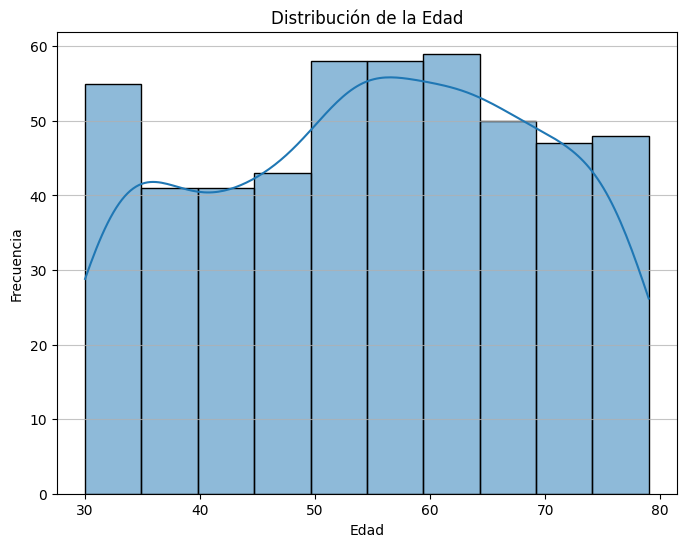

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.histplot(df['Age'], bins=10, kde=True)
plt.title('Distribución de la Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

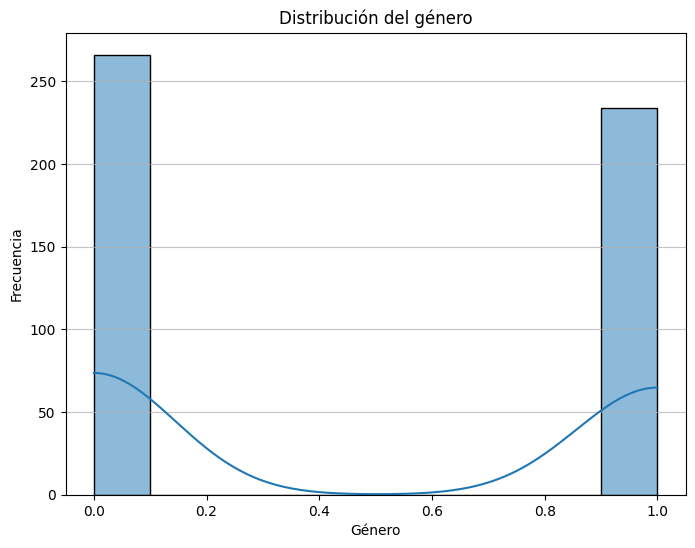

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Gender'], bins=10, kde=True)
plt.title('Distribución del género')
plt.xlabel('Género')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

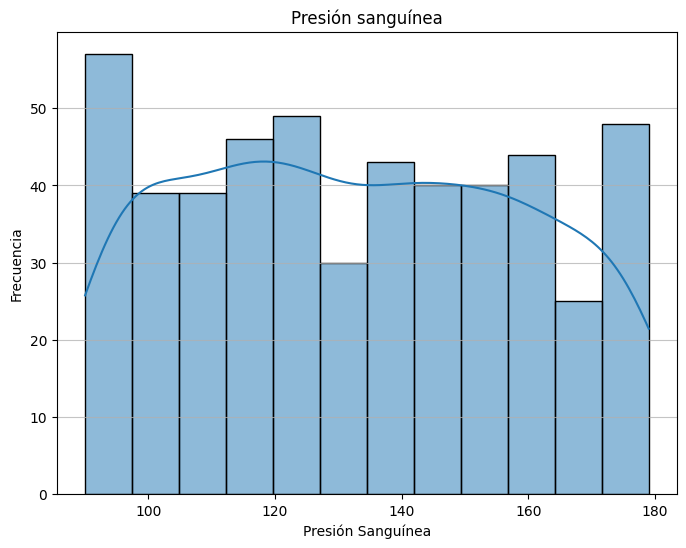

Valor mínimo de BloodPressure: 90
Valor máximo de BloodPressure: 179


In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(df['BloodPressure'], bins=12, kde=True)
plt.title('Presión sanguínea')
plt.xlabel('Presión Sanguínea')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()
min_blood_pressure = df['BloodPressure'].min()
max_blood_pressure = df['BloodPressure'].max()

print(f"Valor mínimo de BloodPressure: {min_blood_pressure}")
print(f"Valor máximo de BloodPressure: {max_blood_pressure}")

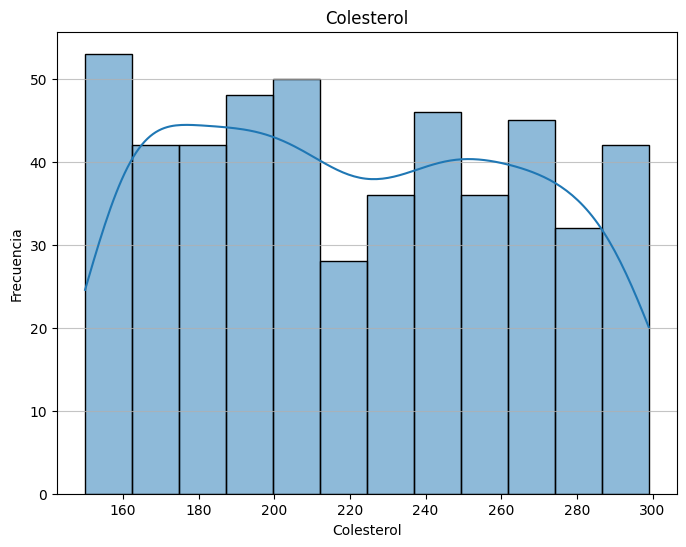

Valor mínimo de Colesterol: 150
Valor máximo de Colesterol: 299


In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Cholesterol'], bins=12, kde=True)
plt.title('Colesterol')
plt.xlabel('Colesterol')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()
min_colesterol= df['Cholesterol'].min()
max_colesterol = df['Cholesterol'].max()

print(f"Valor mínimo de Colesterol: {min_colesterol}")
print(f"Valor máximo de Colesterol: {max_colesterol}")

**Definir X y y**

In [ ]:
X.columns

Index(['Age', 'Gender', 'BloodPressure', 'Cholesterol', 'HeartRate',
       'QuantumPatternFeature'],
      dtype='object')

In [ ]:
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = ['Gender']

# Quitar 'Gender' de las columnas numéricas
numerical_cols = ["Age", "Gender", "BloodPressure", "Cholesterol", "HeartRate"]
numerical_cols = [col for col in numerical_cols if col not in categorical_cols]

X_num = X[numerical_cols]
X_cat = X[categorical_cols]


**Escalarlo**

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

# Escalar col num
X_num_scaled = scaler.fit_transform(X_num)

# Convertir el array escalado de nuevo a un DataFrame
X_num_scaled_df = pd.DataFrame(X_num_scaled, columns=X_num.columns, index=X_num.index)

In [ ]:
# Juntarlas para tener mi X
X_processed = pd.concat([X_num_scaled_df, X_cat], axis=1)

**Aprendizaje automático con MLP**


In [ ]:
from sklearn.neural_network import MLPClassifier

hidden_layer_sizes = (5, 10)
model = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, random_state=42)

**Pipeline**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neural_network import MLPClassifier

# Los transformadores para las columnas numéricas y categóricas
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


numerical_cols_pipeline = X_num.columns.tolist()
categorical_cols_pipeline = X_cat.columns.tolist()

# Preprocesador con ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols_pipeline),
        #('cat', categorical_transformer, categorical_cols_pipeline)
    ])

# Usamos model
mlp_model = MLPClassifier(hidden_layer_sizes=(5, 10), random_state=42)

# Hacer el pipelin
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', mlp_model)
])


display(pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'BloodPressure',
                                                   'Cholesterol',
                                                   'HeartRate'])])),
                ('classifier',
                 MLPClassifier(hidden_layer_sizes=(5, 10), random_state=42))])

In [ ]:
pipeline.fit(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'BloodPressure',
                                                   'Cholesterol',
                                                   'HeartRate'])])),
                ('classifier',
                 MLPClassifier(hidden_layer_sizes=(5, 10), random_state=42))])

In [ ]:
print(f"El score del pipeline es: {pipeline.score(X, y):.4f}")

El score del pipeline es: 0.7780


**Cross Validation**

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

AUC score promedio con 10-folds: 0.8265


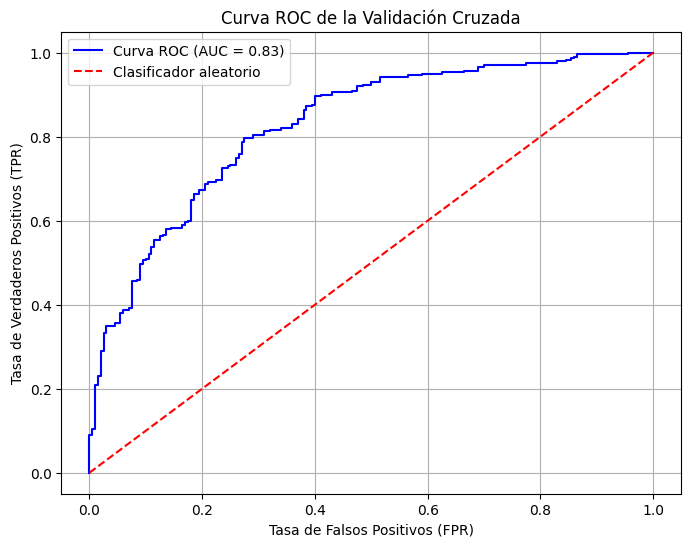

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

y_pred_proba = cross_val_predict(pipeline, X, y, cv=kf, method="predict_proba")[:, 1]

auc_score = roc_auc_score(y, y_pred_proba)
print(f"AUC score promedio con 10-folds: {auc_score:.4f}")

fpr, tpr, thresholds = roc_curve(y, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Curva ROC (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC de la Validación Cruzada')
plt.legend()
plt.grid(True)
plt.show()

con el código de optimización bayeasiana tenemos que buscar la mejor combinación para la red neuronal de datos (neuronas)
tres capas: [2, 6], [5, 15] y [3, 6] (valores entre)

### Bayesian Optimization for Hyperparameter Tuning

Bayesian Optimization is a global optimization strategy for objective functions that are expensive to evaluate. In the context of machine learning, it's particularly useful for hyperparameter tuning. Instead of exhaustively searching a grid or randomly sampling (like Grid Search or Random Search), Bayesian Optimization builds a probabilistic model (a surrogate model) of the objective function and uses this model to propose the next set of hyperparameters to evaluate. This process aims to find the optimal hyperparameters in fewer evaluations.

Here's how it generally works:

1.  **Surrogate Model**: A probabilistic model (e.g., Gaussian Process) is used to approximate the unknown objective function (e.g., cross-validation accuracy).
2.  **Acquisition Function**: An acquisition function (e.g., Expected Improvement) uses the surrogate model to determine which point in the hyperparameter space to sample next. It balances exploration (sampling where the uncertainty is high) and exploitation (sampling where the model predicts a good performance).
3.  **Iterative Process**: The process iterates, updating the surrogate model with new evaluation results and then proposing the next best set of hyperparameters until a stopping criterion is met (e.g., a fixed number of evaluations).

In our case, we will define an `objective` function that takes the `hidden_layer_sizes` as input, trains the `MLPClassifier` within the `Pipeline` using cross-validation, and returns the negative AUC score (since `gp_minimize` performs minimization).

In [ ]:
!pip install scikit-optimize
import numpy as np
from skopt import gp_minimize
from skopt.space import Integer
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Explicitly define X and y from df to ensure they are available
# Based on the original notebook, df is expected to be loaded from '/content/Heart Prediction Quantum Dataset.csv'
if 'df' in globals():
    X = df.drop('HeartDisease', axis=1)
    y = df['HeartDisease']
    print("X and y have been explicitly defined from df.")
else:
    print("Error: 'df' is not defined. Please ensure the dataset is loaded.")

if 'preprocessor' not in locals():
    numerical_cols_for_preprocessor = ['Age', 'BloodPressure', 'Cholesterol', 'HeartRate'] # Assuming 'Gender' was removed from numerical_cols

    numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numerical_cols_for_preprocessor),
        ]
    )
    print("Preprocessor recreated for Bayesian Optimization.")

def objective(params):
    n_neurons_layer1, n_neurons_layer2, n_neurons_layer3 = params
    hidden_layer_sizes = (n_neurons_layer1, n_neurons_layer2, n_neurons_layer3)

    mlp_model_opt = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, random_state=42, max_iter=500, early_stopping=True, n_iter_no_change=20)

    pipeline_opt = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', mlp_model_opt)
    ])

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    try:
        y_pred_proba = cross_val_predict(pipeline_opt, X, y, cv=kf, method="predict_proba", n_jobs=-1)[:, 1]
    except Exception as e:
        print(f"Error during cross_val_predict: {e}")
        return 1.0
    auc_score = roc_auc_score(y, y_pred_proba)

    return -auc_score

Error: 'df' is not defined. Please ensure the dataset is loaded.


In [ ]:

space = [
    Integer(2, 6, name='n_neurons_layer1'),
    Integer(5, 15, name='n_neurons_layer2'),
    Integer(3, 6, name='n_neurons_layer3')
]


res_gp = gp_minimize(objective, space, n_calls=30, random_state=42, verbose=True)

print("\n--- Bayesian Optimization Results ---")
print("Best parameters found:")
print(f"  Layer 1 neurons: {res_gp.x[0]}")
print(f"  Layer 2 neurons: {res_gp.x[1]}")
print(f"  Layer 3 neurons: {res_gp.x[2]}")
print(f"Best negative AUC score (minimized): {res_gp.fun:.4f}")
print(f"Corresponding best AUC score: {-res_gp.fun:.4f}")

best_hidden_layer_sizes = tuple(res_gp.x)
print(f"Optimal hidden_layer_sizes: {best_hidden_layer_sizes}")

Iteration No: 1 started. Evaluating function at random point.
Error during cross_val_predict: name 'X' is not defined
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 0.0018
Function value obtained: 1.0000
Current minimum: 1.0000
Iteration No: 2 started. Evaluating function at random point.
Error during cross_val_predict: name 'X' is not defined
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 0.0023
Function value obtained: 1.0000
Current minimum: 1.0000
Iteration No: 3 started. Evaluating function at random point.
Error during cross_val_predict: name 'X' is not defined
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 0.0007
Function value obtained: 1.0000
Current minimum: 1.0000
Iteration No: 4 started. Evaluating function at random point.
Error during cross_val_predict: name 'X' is not defined
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 0.0007
Function value obtained: 1.0000
Current minimum: 1.0000
Iter

/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(2), np.int64(5), np.int64(6)] before, using random point [np.int64(3), np.int64(13), np.int64(3)]
  warnings.warn(


Iteration No: 16 ended. Search finished for the next optimal point.
Time taken: 0.5276
Function value obtained: 1.0000
Current minimum: 1.0000
Iteration No: 17 started. Searching for the next optimal point.
Error during cross_val_predict: name 'X' is not defined


/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(2), np.int64(5), np.int64(6)] before, using random point [np.int64(5), np.int64(14), np.int64(5)]
  warnings.warn(


Iteration No: 17 ended. Search finished for the next optimal point.
Time taken: 0.4728
Function value obtained: 1.0000
Current minimum: 1.0000
Iteration No: 18 started. Searching for the next optimal point.
Error during cross_val_predict: name 'X' is not defined


...

Iteration No: 27 ended. Search finished for the next optimal point.
Time taken: 0.6005
Function value obtained: 1.0000
Current minimum: 1.0000
Iteration No: 28 started. Searching for the next optimal point.
Error during cross_val_predict: name 'X' is not defined


/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(2), np.int64(5), np.int64(6)] before, using random point [np.int64(6), np.int64(11), np.int64(4)]
  warnings.warn(


Iteration No: 28 ended. Search finished for the next optimal point.
Time taken: 0.7473
Function value obtained: 1.0000
Current minimum: 1.0000
Iteration No: 29 started. Searching for the next optimal point.
Error during cross_val_predict: name 'X' is not defined


/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(2), np.int64(5), np.int64(6)] before, using random point [np.int64(4), np.int64(10), np.int64(6)]
  warnings.warn(


Iteration No: 29 ended. Search finished for the next optimal point.
Time taken: 1.1013
Function value obtained: 1.0000
Current minimum: 1.0000
Iteration No: 30 started. Searching for the next optimal point.
Error during cross_val_predict: name 'X' is not defined
Iteration No: 30 ended. Search finished for the next optimal point.
Time taken: 1.3956
Function value obtained: 1.0000
Current minimum: 1.0000

--- Bayesian Optimization Results ---
Best parameters found:
  Layer 1 neurons: 5
  Layer 2 neurons: 7
  Layer 3 neurons: 5
Best negative AUC score (minimized): 1.0000
Corresponding best AUC score: -1.0000
Optimal hidden_layer_sizes: (np.int64(5), np.int64(7), np.int64(5))
